In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
# 데이터 읽기
df = pd.read_csv(r'pandas/data/titanic_train.csv')
df.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embark_town
0,0,3,male,22.0,1,0,7.2500,Southampton
1,1,1,female,38.0,1,0,71.2833,Cherbourg
2,1,3,female,26.0,0,0,7.9250,Southampton


In [4]:
# 기본 정보 확인하기
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embark_town  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [ ]:
'''
age 컬럼과 embark_town 컬럼에서 결측치가 확인된다.
결측치를 삭제하지말고 새로운 데이터로 보강하세요
'''
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# 원본 데이터로부터 복사본 생성
df_knn = df.copy()

# 스케일러 생성
scaler = StandardScaler()

# 숫자들로만 이루어진 새로운 데이터프레임(df_numeric)으로 컬럼 필터링
df_numeric_cols = df_knn.select_dtypes(np.number).columns.to_list()
df_numeric = pd.DataFrame(
    scaler.fit_transform(df_knn[df_numeric_cols]), 
    index=df_knn.index, 
    columns=df_numeric_cols
)

df_numeric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    float64
 1   pclass    891 non-null    float64
 2   age       714 non-null    float64
 3   sibsp     891 non-null    float64
 4   parch     891 non-null    float64
 5   fare      891 non-null    float64
dtypes: float64(6)
memory usage: 41.9 KB


In [15]:
df_numeric.describe()

,survived,pclass,age,sibsp,parch,fare
count,8.910000e+02,8.910000e+02,7.140000e+02,8.910000e+02,8.910000e+02,8.910000e+02
mean,3.987333e-17,-8.772133e-17,2.388379e-16,4.386066e-17,5.382900e-17,3.987333e-18
std,1.000562e+00,1.000562e+00,1.000701e+00,1.000562e+00,1.000562e+00,1.000562e+00
min,-7.892723e-01,-1.566107e+00,-2.016979e+00,-4.745452e-01,-4.736736e-01,-6.484217e-01
25%,-7.892723e-01,-3.693648e-01,-6.595416e-01,-4.745452e-01,-4.736736e-01,-4.891482e-01
50%,-7.892723e-01,8.273772e-01,-1.170488e-01,-4.745452e-01,-4.736736e-01,-3.573909e-01
75%,1.266990e+00,8.273772e-01,5.718310e-01,4.327934e-01,-4.736736e-01,-2.424635e-02
max,1.266990e+00,8.273772e-01,3.465126e+00,6.784163e+00,6.974147e+00,9.667167e+00


In [16]:
df_numeric.head()

,survived,pclass,age,sibsp,parch,fare
0,-0.789272,0.827377,-0.530377,0.432793,-0.473674,-0.502445
1,1.266990,-1.566107,0.571831,0.432793,-0.473674,0.786845
2,1.266990,0.827377,-0.254825,-0.474545,-0.473674,-0.488854
3,1.266990,-1.566107,0.365167,0.432793,-0.473674,0.420730
4,-0.789272,0.827377,0.365167,-0.474545,-0.473674,-0.486337


In [20]:
# KNNImputer 인스턴스 생성
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')

# knn_imputer를 이용하여 결측치 대체
df_imputed_scaled = pd.DataFrame(
    knn_imputer.fit_transform(df_numeric),
    columns=df_numeric_cols,
    index=df_knn.index
)
# 결측치가 
df_imputed_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    float64
 1   pclass    891 non-null    float64
 2   age       891 non-null    float64
 3   sibsp     891 non-null    float64
 4   parch     891 non-null    float64
 5   fare      891 non-null    float64
dtypes: float64(6)
memory usage: 41.9 KB


In [21]:
# 역변환 및 결측치를 보완한 열을 원본 데이터에 대치
df_imputed = pd.DataFrame(
    scaler.inverse_transform(df_imputed_scaled),
    index=df_knn.index,
    columns=df_numeric_cols
)

df_imputed.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    float64
 1   pclass    891 non-null    float64
 2   age       891 non-null    float64
 3   sibsp     891 non-null    float64
 4   parch     891 non-null    float64
 5   fare      891 non-null    float64
dtypes: float64(6)
memory usage: 41.9 KB


In [22]:
df_knn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embark_town  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [23]:
df_knn['age'] = df_imputed['age']
df_knn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embark_town  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [28]:
na_cnt = df_knn['embark_town'].isnull().sum()
print(f'결측치 개수: {na_cnt}개')
print(f'결측치 비율: {na_cnt/len(df_knn)*100:.3f}%')

결측치 개수: 2개
결측치 비율: 0.224%


In [30]:
# 결측치 비율이 매우 적으므로 삭제로 처리함
df_clean = df_knn.dropna()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     889 non-null    int64  
 1   pclass       889 non-null    int64  
 2   sex          889 non-null    object 
 3   age          889 non-null    float64
 4   sibsp        889 non-null    int64  
 5   parch        889 non-null    int64  
 6   fare         889 non-null    float64
 7   embark_town  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB


In [34]:
import warnings
warnings.filterwarnings('ignore')  # 경고 메시지 숨김

# 한글 폰트 설정 (macOS 기준)
plt.rcParams['font.family'] = 'AppleGothic'        # macOS 한글 폰트
plt.rcParams['axes.unicode_minus'] = False          # 마이너스 부호 깨짐 방지
plt.rcParams['figure.figsize'] = (10, 6)            # 기본 그래프 크기
plt.rcParams['figure.dpi'] = 100                    # 해상도

# Jupyter 노트북에서 그래프 인라인 표시
%matplotlib inline

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5334 entries, 0 to 5333
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   컬럼      5334 non-null   object 
 1   값       5334 non-null   float64
dtypes: float64(1), object(1)
memory usage: 83.5+ KB
None


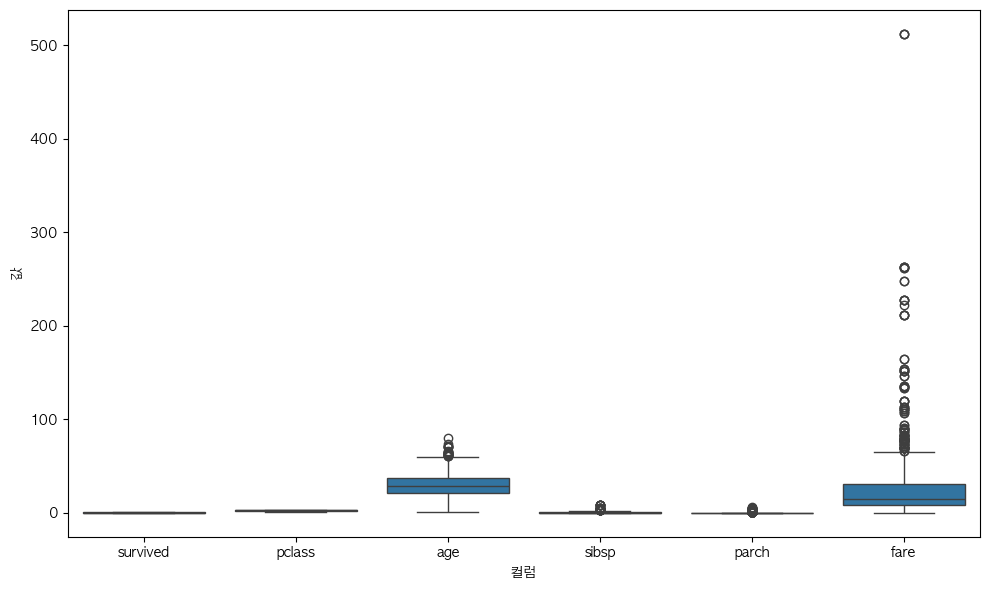

In [37]:
# 이상치 확인하기
# boxplot을 이용하여 시각적 확인
# # melt(): 여러 컬럼을 세로로 녹여서 하나의 '특성'+'값' 컬럼으로 변환
df_numeric_melted = df_clean.copy()[df_numeric_cols].melt(var_name='컬럼', value_name='값')
print(df_numeric_melted.info())
sns.boxplot(data=df_numeric_melted, x='컬럼', y='값')
plt.tight_layout()
plt.show()
